# Simple Logistic Regression — MS Subtype Classification

**Goal:** Predict which MS subtype (RRMS, SPMS, PPMS) a patient has based on clinical and MRI features.

**About Logistic Regression:** A simple linear model that predicts class probabilities using the softmax function. It gives us a baseline and interpretable coefficients.

---

In [1]:
# Import all the libraries we need
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_auc_score, roc_curve, auc, precision_recall_curve, average_precision_score
)
from sklearn.linear_model import LogisticRegression
# Set seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings('ignore')

# Plot settings
plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 13,
    'figure.figsize': (10, 6), 'axes.grid': True, 'grid.alpha': 0.3,
})

COLORS = {'RRMS': '#2196F3', 'SPMS': '#FF5722', 'PPMS': '#4CAF50'}
ORDER = ['RRMS', 'SPMS', 'PPMS']

print("All libraries loaded successfully!")

All libraries loaded successfully!


## 2. Loading the Dataset

We load the CSV file and take a quick look at its shape and first few rows.

In [2]:
df = pd.read_csv('../datasets/ms_dataset.csv')
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()

Rows: 525, Columns: 17


,age,sex_encoded,age_at_onset,edss,disease_duration,relapse_count,treatment_status,brain_volume,gm_volume,wm_volume,lesion_count,lesion_volume,edss_progression_rate,gm_ratio,wm_ratio,lesion_burden_ratio,subtype
0,44.0,0,38.0,6.0,6.0,0.0,0.0,1028167.8,621739.1,474379.0,36.0,6807.9,0.2617,0.604700,0.461400,0.006621,PPMS
1,50.0,1,47.0,5.7,3.0,0.0,0.0,1309256.4,442370.6,466771.9,34.0,21719.1,0.4633,0.337900,0.356500,0.016589,PPMS
2,31.0,0,29.0,2.5,2.0,0.0,0.0,1493401.0,742487.0,513052.0,6.0,200.0,1.2500,0.497179,0.343546,0.000134,RRMS
3,50.0,0,42.0,5.7,8.0,0.0,1.0,1347866.4,604577.7,460298.3,3.0,19638.3,0.5694,0.448500,0.341500,0.014570,PPMS
4,45.0,0,35.0,5.5,10.0,0.0,1.0,1305379.0,627683.0,420957.0,24.0,20854.0,0.5500,0.480843,0.322479,0.015975,SPMS


## 3. Exploring the Data

Before building a model, we need to understand our data — check for missing values, see how many patients are in each subtype, and look at feature distributions.

### 3.1 Basic Info

In [3]:
print("Data types:")
print(df.dtypes)
print("\nBasic statistics:")
df.describe().round(2)

Data types:
age                      float64
sex_encoded                int64
age_at_onset             float64
edss                     float64
disease_duration         float64
relapse_count            float64
treatment_status         float64
brain_volume             float64
gm_volume                float64
wm_volume                float64
lesion_count             float64
lesion_volume            float64
edss_progression_rate    float64
gm_ratio                 float64
wm_ratio                 float64
lesion_burden_ratio      float64
subtype                      str
dtype: object

Basic statistics:


,age,sex_encoded,age_at_onset,edss,disease_duration,relapse_count,treatment_status,brain_volume,gm_volume,wm_volume,lesion_count,lesion_volume,edss_progression_rate,gm_ratio,wm_ratio,lesion_burden_ratio
count,525.00,525.00,525.00,525.00,525.00,525.00,525.00,525.00,525.00,525.00,525.00,525.00,499.00,525.00,525.00,525.00
mean,42.14,0.39,34.04,3.43,8.10,0.53,0.63,1355664.55,636212.88,437801.76,33.31,10327.57,0.73,0.47,0.33,0.01
std,12.46,0.49,10.18,2.08,6.57,0.62,0.48,156263.27,102463.45,60392.49,43.33,10127.20,1.02,0.08,0.05,0.01
min,15.00,0.00,7.50,0.00,0.00,0.00,0.00,922515.10,368110.90,268459.00,1.00,200.00,0.00,0.29,0.19,0.00
25%,32.20,0.00,27.00,2.00,3.20,0.00,0.00,1256271.00,573081.00,398724.00,13.00,2585.00,0.24,0.43,0.29,0.00
50%,41.70,0.00,34.00,3.00,6.20,0.00,1.00,1362968.00,643607.00,442397.00,24.00,7363.00,0.44,0.47,0.33,0.01
75%,51.60,1.00,41.00,5.00,12.00,1.00,1.00,1462525.31,710497.00,474379.00,41.00,14702.60,0.77,0.52,0.35,0.01
max,71.00,1.00,65.00,8.50,35.00,2.00,1.00,1724642.00,884733.00,628779.00,497.00,60999.00,10.00,0.86,0.49,0.05


In [4]:
# Check for missing values
missing = df.isnull().sum()
print("Missing values:")
print(missing[missing > 0])
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values:
edss_progression_rate    26
dtype: int64

Duplicate rows: 0


### 3.2 How Many Patients in Each Subtype?

subtype
RRMS    275
SPMS    125
PPMS    125
Name: count, dtype: int64


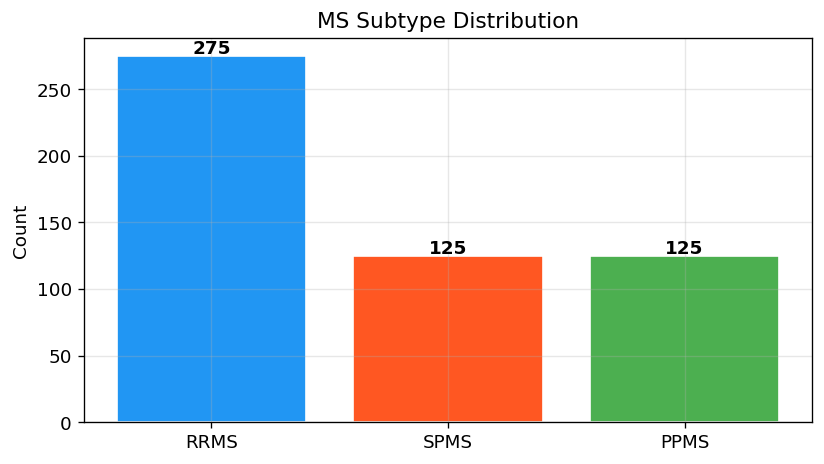

In [5]:
counts = df['subtype'].value_counts().reindex(ORDER)
print(counts)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(ORDER, counts, color=[COLORS[s] for s in ORDER], edgecolor='white')
for b, c in zip(bars, counts):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 2, str(c), ha='center', fontweight='bold')
ax.set_ylabel('Count')
ax.set_title('MS Subtype Distribution')
plt.tight_layout()
plt.show()

### 3.3 Feature Distributions by Subtype

Boxplots help us see which features differ across subtypes — features with clear separation will be helpful for classification.

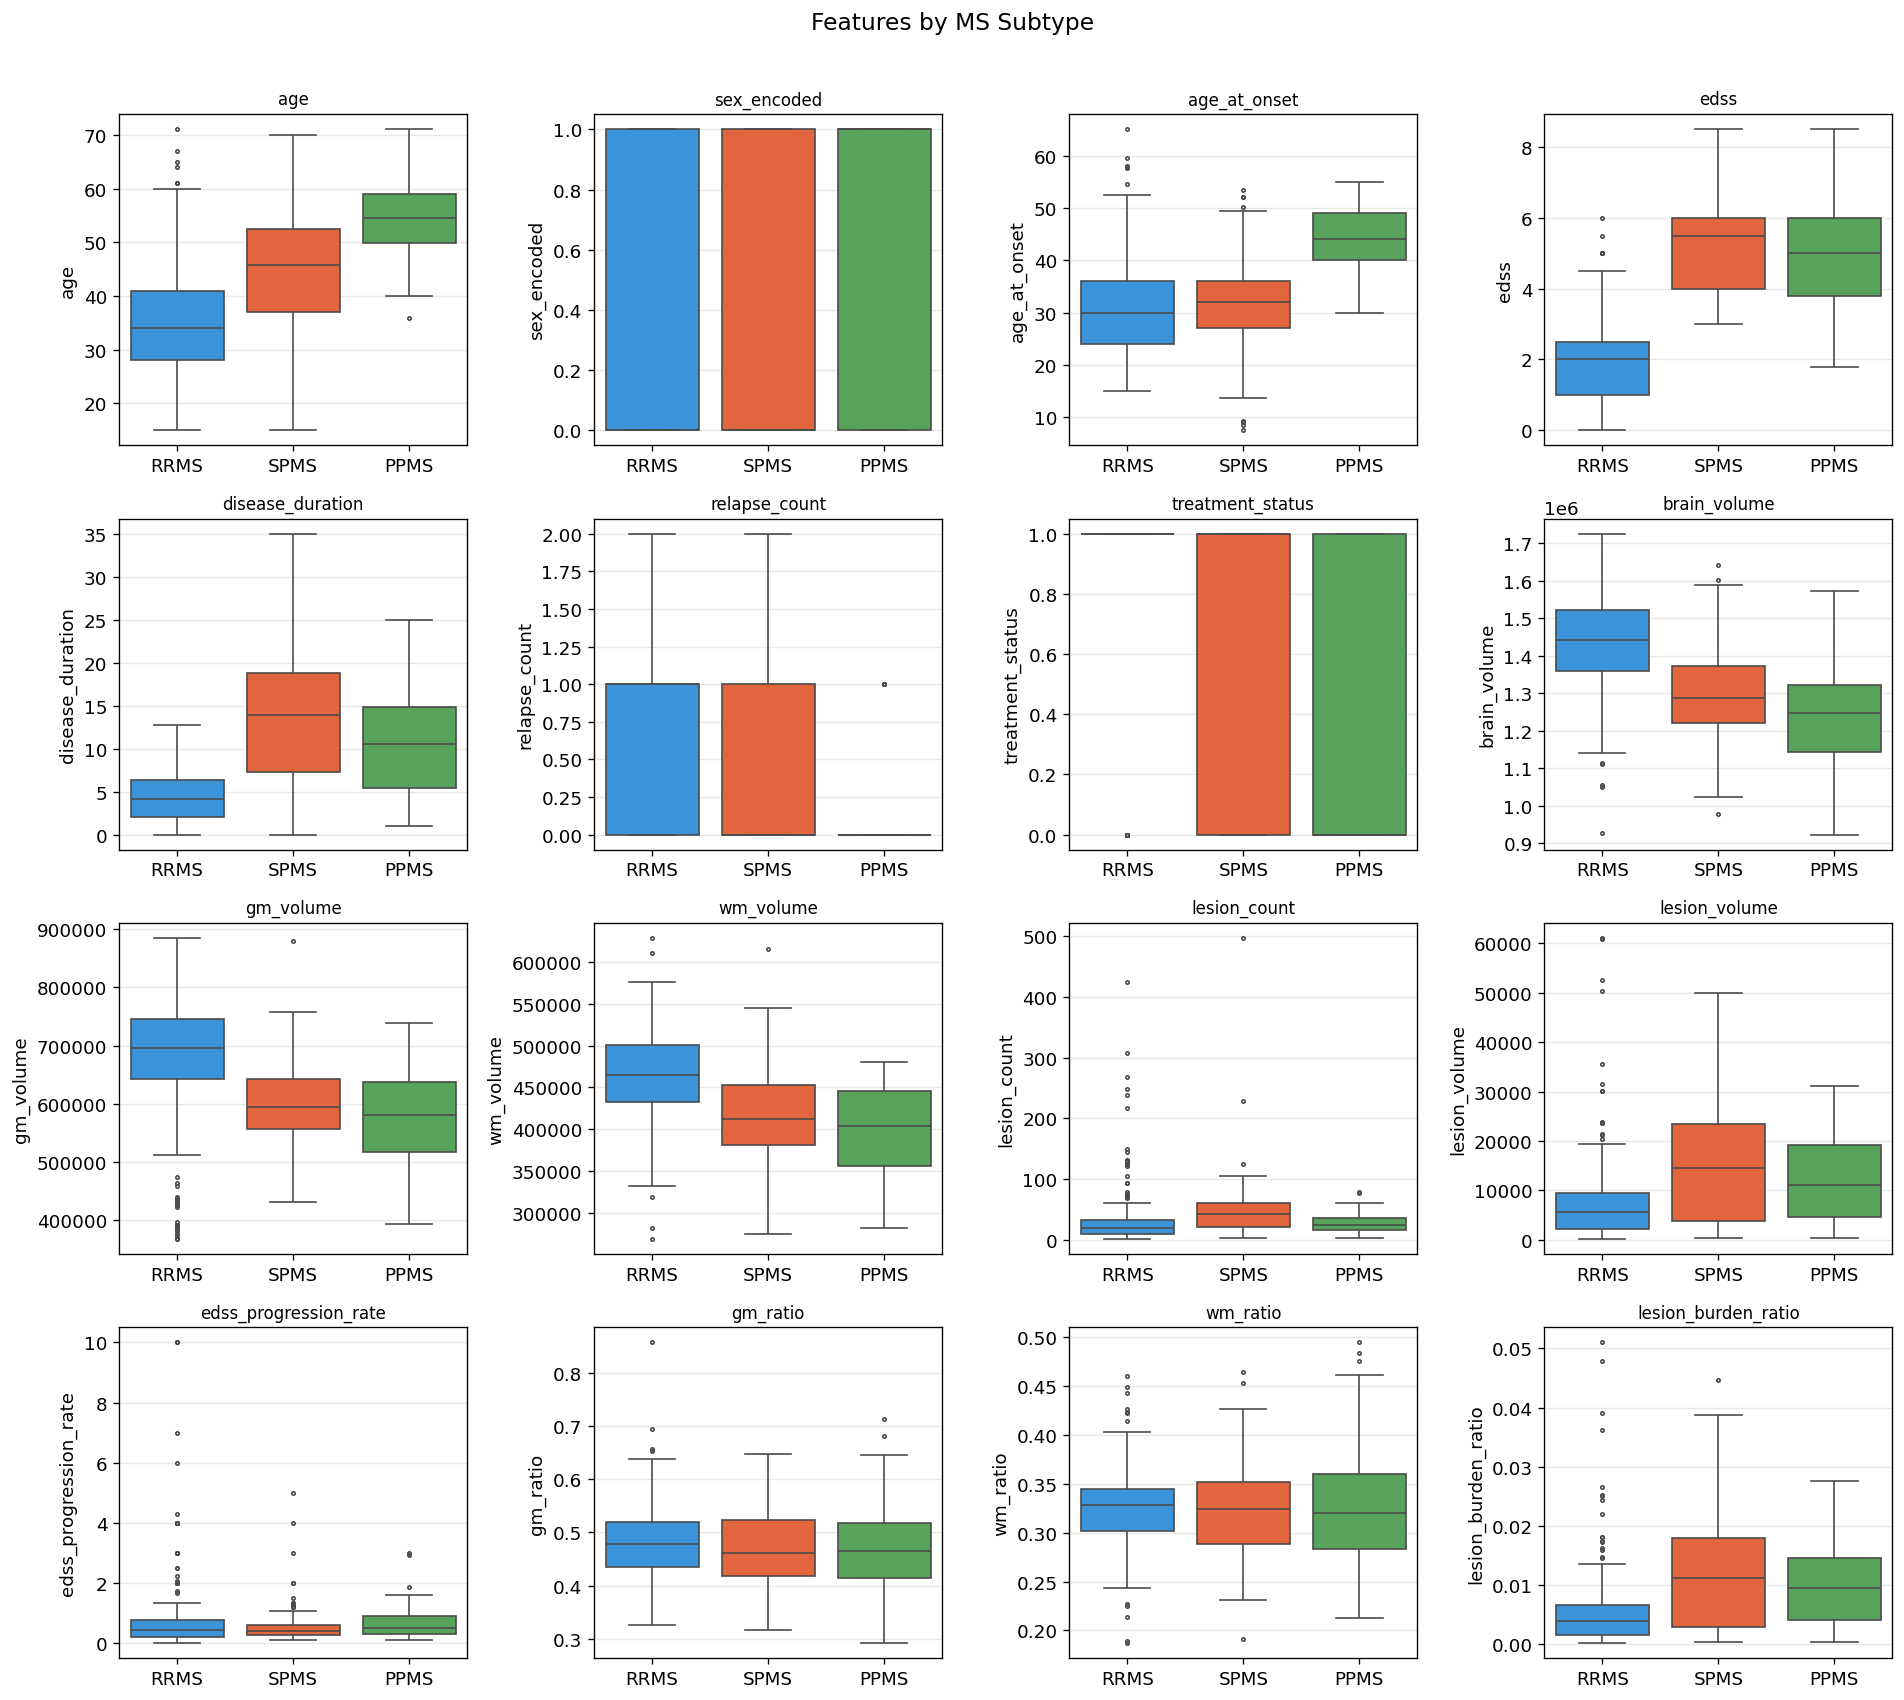

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
ncols = 4
nrows = (len(numeric_cols) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='subtype', y=col, order=ORDER, palette=COLORS, ax=axes[i], fliersize=2)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Features by MS Subtype', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 3.4 Correlation Heatmap

Shows how features relate to each other. Highly correlated features carry similar information.

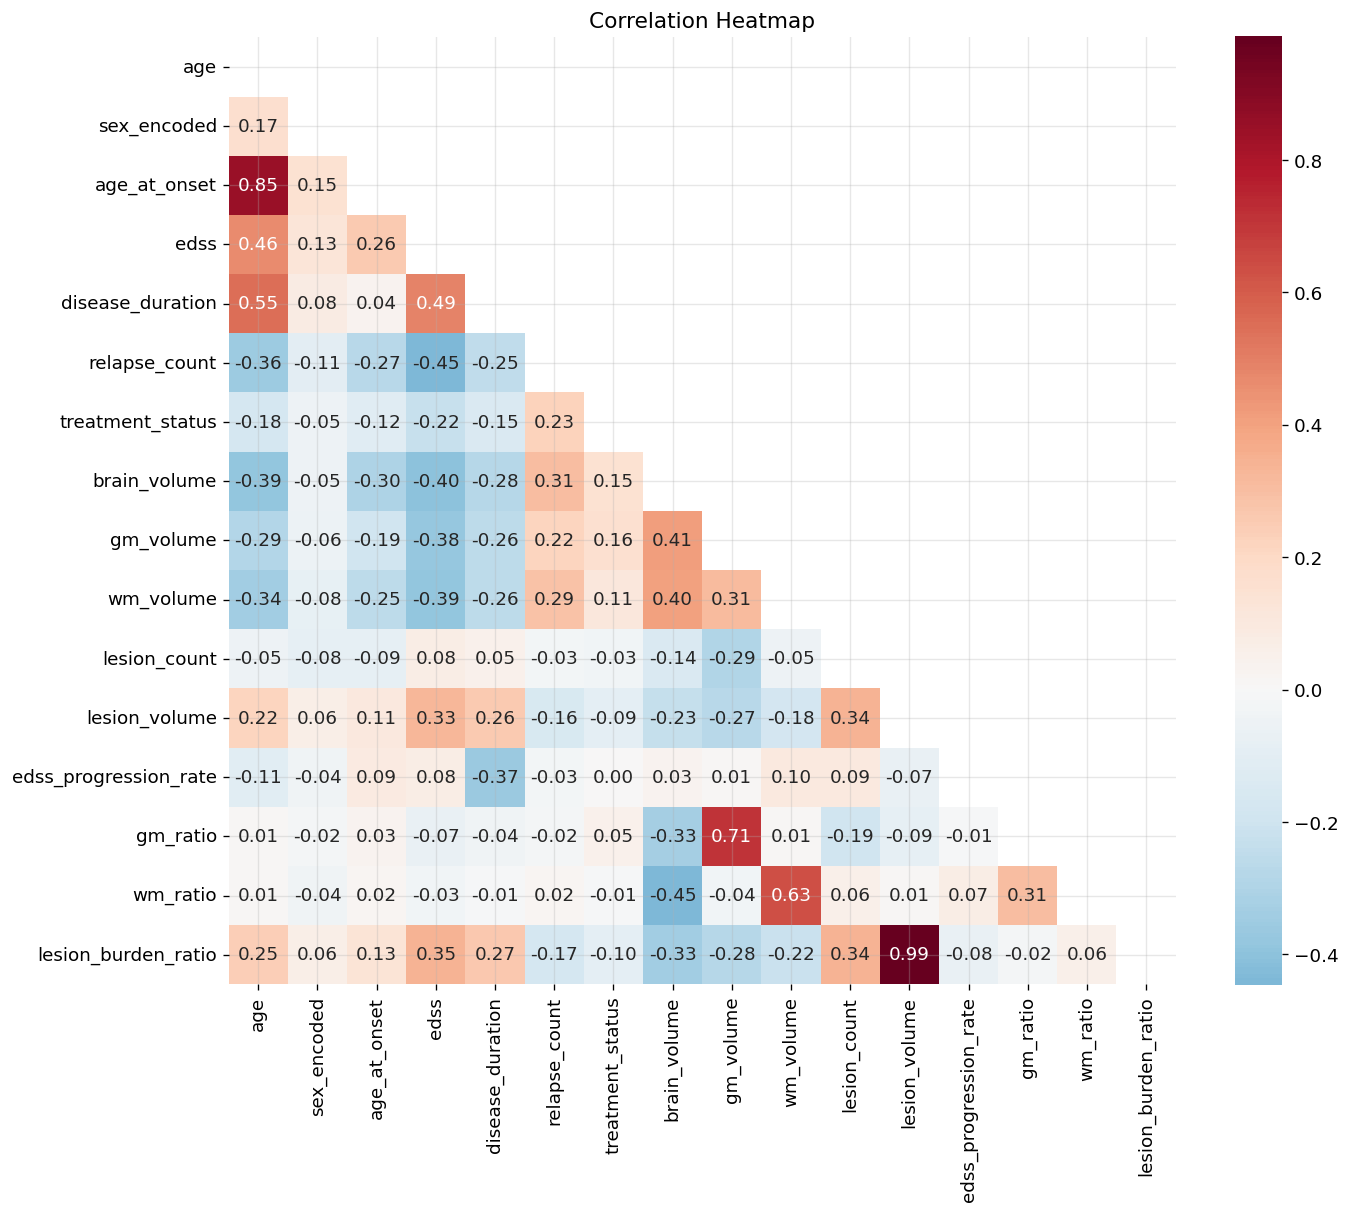

In [7]:
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True, ax=ax)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

Steps:
1. Separate features (X) from target (y)
2. Encode target labels as numbers
3. Split into 80% train / 20% test
4. Fill missing values with the median
5. Scale features to mean=0, std=1

**Important:** We fit the imputer only on training data to prevent data leakage.

In [8]:
# Separate features and target
feature_cols = [c for c in df.columns if c != 'subtype']
X = df[feature_cols]
y = df['subtype']

# Encode target as numbers
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_
print(f"Classes: {list(class_names)}")

Classes: ['PPMS', 'RRMS', 'SPMS']


In [9]:
# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=RANDOM_STATE, stratify=y_encoded
)
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

Train: 420, Test: 105


In [10]:
# Fill missing values with median
imputer = SimpleImputer(strategy='median')
X_train_clean = imputer.fit_transform(X_train)
X_test_clean = imputer.transform(X_test)

# Scale features (important for Logistic Regression)
scaler = StandardScaler()
X_train_ready = scaler.fit_transform(X_train_clean)
X_test_ready = scaler.transform(X_test_clean)
print("Data scaled (mean=0, std=1)")
print(f"Missing values remaining: 0")

Data scaled (mean=0, std=1)
Missing values remaining: 0


## 5. Building the Model

Logistic Regression with L2 regularization and balanced class weights.

In [11]:
model = LogisticRegression(
    penalty='l2', solver='lbfgs', max_iter=1000,
    class_weight='balanced', C=1.0, random_state=RANDOM_STATE
)
print("Model created")

Model created


## 6. Cross-Validation (5-Fold)

We split training data into 5 parts, train on 4 and test on 1, rotating each time. This tells us how stable the model is.

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {'accuracy': 'accuracy', 'f1_macro': 'f1_macro', 'f1_weighted': 'f1_weighted'}

cv_results = cross_validate(model, X_train_ready, y_train, cv=cv, scoring=scoring)

print("Cross-Validation Results:")
print(f"  Accuracy:     {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")
print(f"  Macro F1:     {cv_results['test_f1_macro'].mean():.4f} ± {cv_results['test_f1_macro'].std():.4f}")
print(f"  Weighted F1:  {cv_results['test_f1_weighted'].mean():.4f} ± {cv_results['test_f1_weighted'].std():.4f}")

Cross-Validation Results:
  Accuracy:     0.8762 ± 0.0307
  Macro F1:     0.8484 ± 0.0430
  Weighted F1:  0.8766 ± 0.0316


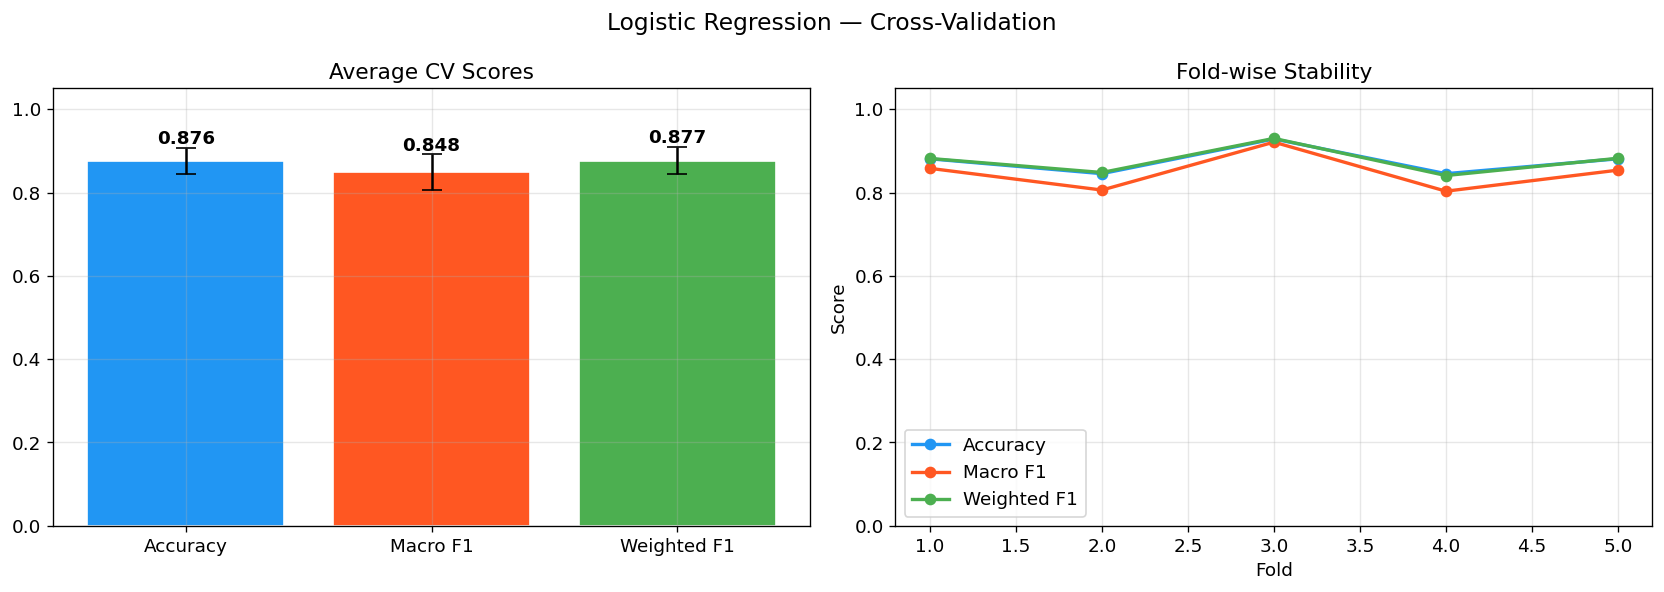

In [13]:
# Visualize CV results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names = ['Accuracy', 'Macro F1', 'Weighted F1']
means = [cv_results[f'test_{m}'].mean() for m in ['accuracy', 'f1_macro', 'f1_weighted']]
stds = [cv_results[f'test_{m}'].std() for m in ['accuracy', 'f1_macro', 'f1_weighted']]
axes[0].bar(names, means, yerr=stds, capsize=6, color=['#2196F3', '#FF5722', '#4CAF50'], edgecolor='white')
for i, (m, s) in enumerate(zip(means, stds)):
    axes[0].text(i, m + s + 0.01, f'{m:.3f}', ha='center', fontweight='bold')
axes[0].set_ylim(0, 1.05)
axes[0].set_title('Average CV Scores')

for key, label, c in [('test_accuracy','Accuracy','#2196F3'), ('test_f1_macro','Macro F1','#FF5722'), ('test_f1_weighted','Weighted F1','#4CAF50')]:
    axes[1].plot(range(1,6), cv_results[key], 'o-', label=label, color=c, linewidth=2)
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('Score')
axes[1].set_title('Fold-wise Stability')
axes[1].legend()
axes[1].set_ylim(0, 1.05)

plt.suptitle('Logistic Regression — Cross-Validation', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Train on Full Training Set

In [14]:
model.fit(X_train_ready, y_train)
print("Model trained!")

Model trained!


## 8. Test Set Evaluation

Now we test on data the model has never seen.

In [15]:
y_pred = model.predict(X_test_ready)
y_proba = model.predict_proba(X_test_ready)

print("Test Results:")
print(f"  Accuracy:     {accuracy_score(y_test, y_pred):.4f}")
print(f"  Macro F1:     {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"  Weighted F1:  {f1_score(y_test, y_pred, average='weighted'):.4f}")
print("\n" + classification_report(y_test, y_pred, target_names=class_names, digits=4))

Test Results:
  Accuracy:     0.8571
  Macro F1:     0.8270
  Weighted F1:  0.8581

              precision    recall  f1-score   support

        PPMS     0.8000    0.8000    0.8000        25
        RRMS     0.9444    0.9273    0.9358        55
        SPMS     0.7308    0.7600    0.7451        25

    accuracy                         0.8571       105
   macro avg     0.8251    0.8291    0.8270       105
weighted avg     0.8592    0.8571    0.8581       105



### Confusion Matrix

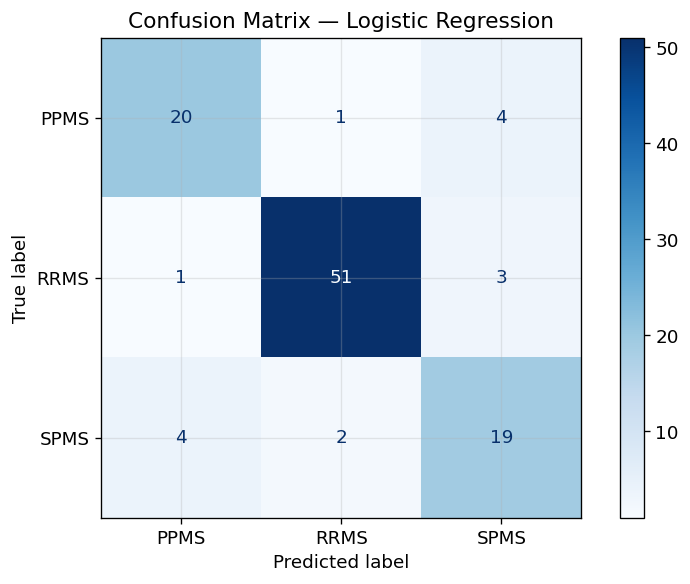

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.show()

### ROC Curves

Closer to the top-left corner = better. AUC of 1.0 is perfect, 0.5 is random guessing.

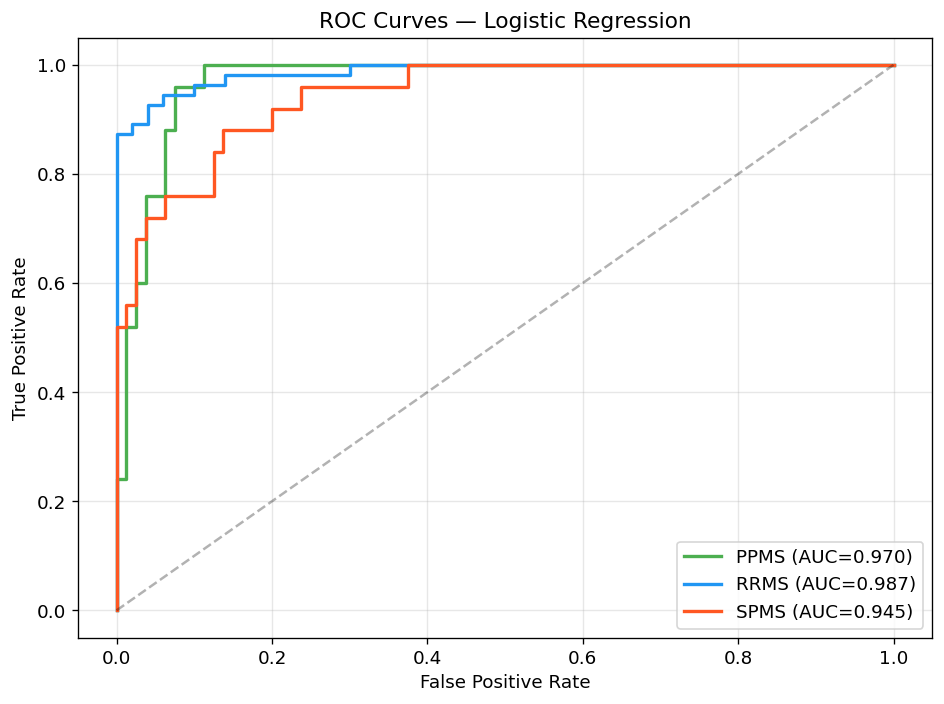

Overall ROC-AUC: 0.9674


In [17]:
y_test_bin = label_binarize(y_test, classes=range(len(class_names)))

fig, ax = plt.subplots(figsize=(8, 6))
for i, name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    ax.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc(fpr,tpr):.3f})', color=COLORS.get(name))
ax.plot([0,1],[0,1],'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Logistic Regression')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Overall ROC-AUC: {roc_auc_score(y_test_bin, y_proba, multi_class='ovr', average='macro'):.4f}")

### Precision-Recall Curves

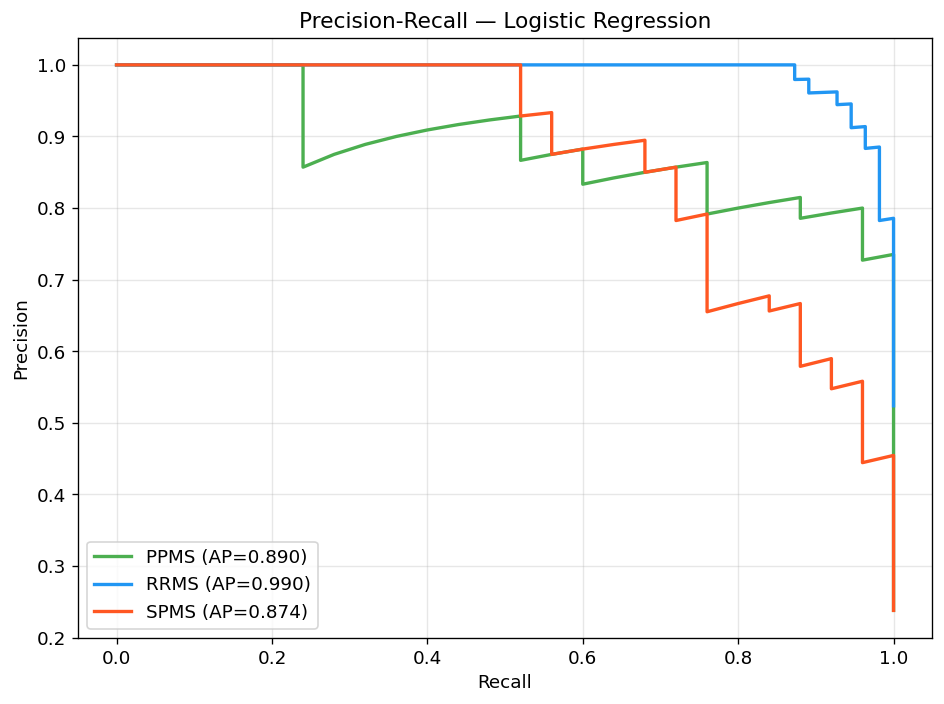

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))
for i, name in enumerate(class_names):
    prec, rec, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_proba[:, i])
    ax.plot(rec, prec, linewidth=2, label=f'{name} (AP={ap:.3f})', color=COLORS.get(name))
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall — Logistic Regression')
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

## 9. Coefficient Heatmap

Shows how each feature pushes toward or away from each subtype.

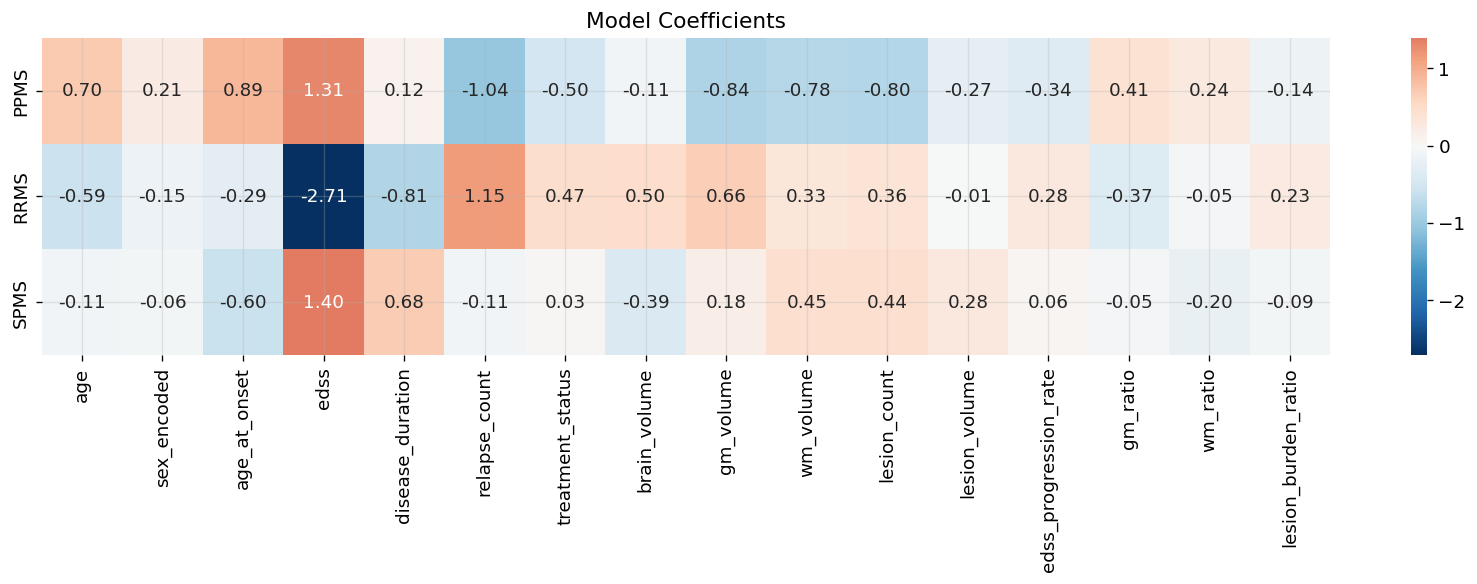

In [19]:
coef_df = pd.DataFrame(model.coef_, index=class_names, columns=feature_cols)
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(coef_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Model Coefficients')
plt.tight_layout()
plt.show()

## Conclusion

Logistic Regression gives us a simple interpretable baseline. The coefficients tell us which features matter most for each subtype.